# XGBoost and AdaBoost

In this notebook, we implements and evaluates ensamble models based on boosting to predict fuel efficiency in miles per gallon (MPG).

The dataset used in this notebook is the same one previously processed in the EDA section. It uses unscaled data (`train_raw` / `test_raw`), since tree-based models do not require variable normalization.

The models implemented are:

+ AdaBoost (Baseline and optimized with GridSearchCV)

+ XGBoost (Baseline and optimized with GridSearchCV)

The exploratory data analysis showed non-linear variables relationships between `weight`, `displacement`, `hosepower` and `cylinders` with `mpg`. Boosting models are especially appropriate for capturing these this patterns, since they continuously build weaks learners (decision trees) and combined them to create a strong model.

AdaBoost adjuste the weights of misclassified observations in each iteration, whareas XGBoost optimizes a loss function with $L1$ and $L2$ regularization. Consenquently, XGBoost are more robust against overfitting.

The comparison are conducted using the following metrics:

+ MAE (Mean Absolute Error)
+ RMSE (Root Mean Squared Error)
+ $R^2$ (Coefficient of Determination)

# 1. Environment Setup



In [ ]:
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import(
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

In [4]:
from pathlib import Path
import os
import random
import numpy as np

#===================================
# project configuration
#===================================

# Routes

#project root directory
BASE         = Path.cwd().parent

# project directories
DATA         = BASE / "data"
PROCESSED_DATA = DATA / "processed"
FIGURES = BASE / "figures"
RESULTS = BASE / "results"
MODELS = BASE / "models"


RANDOM_STATE = 42

#reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Create directories if they do not exist
for directory in [
    PROCESSED_DATA,
    FIGURES,
    RESULTS,
    MODELS
]:
    directory.mkdir(parents=True, exist_ok=True)

# ============================================================
# CONFIGURATION CHECK
# ============================================================

print("Configuration ready\n")

print(f"BASE          : {BASE}")
print(f"DATA          : {DATA}")
print(f"PROCESSED_DATA: {PROCESSED_DATA}")
print(f"FIGURES       : {FIGURES}")
print(f"RESULTS       : {RESULTS}")
print(f"MODELS        : {MODELS}")
print(f"RANDOM_STATE  : {RANDOM_STATE}")


Configuration ready

BASE          : /
DATA          : /data
PROCESSED_DATA: /data/processed
FIGURES       : /figures
RESULTS       : /results
MODELS        : /models
RANDOM_STATE  : 42


# **2.- Train-Test Split**

In [6]:
# data unscaled
#AdaBoost and XGBoost are tree-based models and
# therefore do not require scaled variables.
#We used train_raw and train_raw directly.

train = pd.read_csv('train_raw.csv')
test  = pd.read_csv('test_raw.csv')

X_train = train.drop('mpg', axis=1)
y_train = train['mpg']
X_test  = test.drop('mpg', axis=1)
y_test  = test['mpg']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Columnas: {list(X_train.columns)}')


Train: (318, 8) | Test: (80, 8)
Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']


+ The-threes models (such as AdaBoost and XGBoost) do not require feature scaling because they do not calculate distances or use penalties. These models make splits based on binary values. We using unscaled data facilitates the interpretation of variable importance in original units.

# **3.- AdaBoost**


We want to approximate miles per gallon based on a car's mechanical features.

We want do:

$$mpg = f(x_1, x_2, ... , x_n)$$

## **3.1 .- Baseline Model**

We defined our baseline tree model.

In [8]:
tree_base = DecisionTreeRegressor(max_depth=5, random_state = 42)

We defined AdaBoost model:

In [10]:
ADA = AdaBoostRegressor(
    estimator = tree_base,
    n_estimators= 400,
    learning_rate = 0.07,
    random_state=42
)

Training

In [11]:
Y_train_log = np.log1p(y_train)

ADA.fit(X_train, Y_train_log)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
                  learning_rate=0.07, n_estimators=400, random_state=42)

We make log-transformed predictions

In [12]:
y_pred_log = ADA.predict(X_test)

Predictions:

In [13]:
y_pred_ada = np.expm1(y_pred_log)

We evaluate the model using **RMSE**, **LMSE** and **MAE**

In [17]:
mse_ADA =mean_squared_error(
    y_test,
    y_pred_ada
)

rmse_ADA = np.sqrt(mse_ADA)

mae_ADA = mean_absolute_error(
    y_test,
    y_pred_ada
)

r2_ADA = r2_score(y_test, y_pred_ada)

print(f'RMSE : {rmse_ADA}')
print(f'MSE: {mse_ADA}')
print(f'MAE: {mae_ADA}')
print(f'R^2: {r2_ADA}')

RMSE : 2.4324171144388878
MSE: 5.9166530186152055
MAE: 1.7400086656712446
R^2: 0.8899564002014695


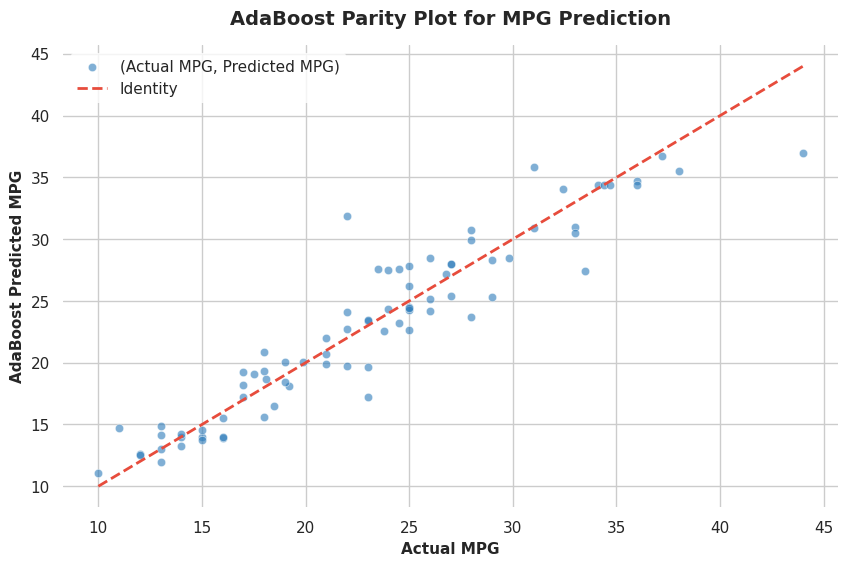

In [19]:
sns.set_theme(style='whitegrid', context = "notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            y_pred_ada,
            color = '#2b7bba',
            alpha = 0.6,
            edgecolors = 'w',
            linewidths = 0.5,
            label = '(Actual MPG, Predicted MPG)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
       color = '#e74c3c',
       linestyle ='--',
       linewidth = 2,
       label = 'Identity'

)
plt.title('AdaBoost Parity Plot for MPG Prediction', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('Actual MPG', fontsize = 11, fontweight = 'semibold')
plt.ylabel('AdaBoost Predicted MPG', fontsize =11, fontweight = 'semibold')
plt.legend(frameon = True, facecolor='white', edgecolor='none')
sns.despine(left = True, bottom = True)

plt.show()

## **3.2 .- GridSearchCV for AdaBoost**

Hyperparameter Tuning: We defined the parameters grid.

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

param_grid_ADA = {
    'estimator__max_depth' : [3,4,5],
    'n_estimators' : [200, 300, 400],
    'learning_rate' : [0.02, 0.04, 0.05],
    'loss' : ['linear', 'square']
}

#croos fold
cross_fold = KFold(n_splits = 5, shuffle=True, random_state=42)

In [22]:
from sklearn.model_selection import GridSearchCV

grid_ADA = GridSearchCV(
    estimator = ADA,
    param_grid = param_grid_ADA,
    cv = cross_fold,
    scoring = 'r2',
    n_jobs = -1
)

We training the model

In [23]:
grid_ADA.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5,
                                                                         random_state=42),
                                         learning_rate=0.07, n_estimators=400,
                                         random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [3, 4, 5],
                         'learning_rate': [0.02, 0.04, 0.05],
                         'loss': ['linear', 'square'],
                         'n_estimators': [200, 300, 400]},
             scoring='r2')

We see the best estimators

In [24]:
print(grid_ADA.best_params_)

best_ADA_grid = grid_ADA.best_estimator_

{'estimator__max_depth': 5, 'learning_rate': 0.05, 'loss': 'linear', 'n_estimators': 300}


We retrieved the best modelac cording to GridSearchCV

In [25]:
pred_ADA_grid = best_ADA_grid.predict(X_test)

We calculate metrics

In [26]:
mse_grid_ada = mean_squared_error(y_test, pred_ADA_grid)
rmse_grid_ada = mse_grid_ada**0.5
mae_grid_ada = mean_absolute_error(y_test, pred_ADA_grid)
r2_grid_ada = r2_score(y_test, pred_ADA_grid)

print(f'RMSE: {rmse_grid_ada}')
#print(f'MSE: {mse_grid_ada}')
print(f'MAE: {mae_grid_ada}')
print(f'R^2: {r2_grid_ada}')

RMSE: 2.2466583568591294
MAE: 1.6681324069634509
R^2: 0.9061222312579496


Visualitation AdaBoost according to GridSearchCV

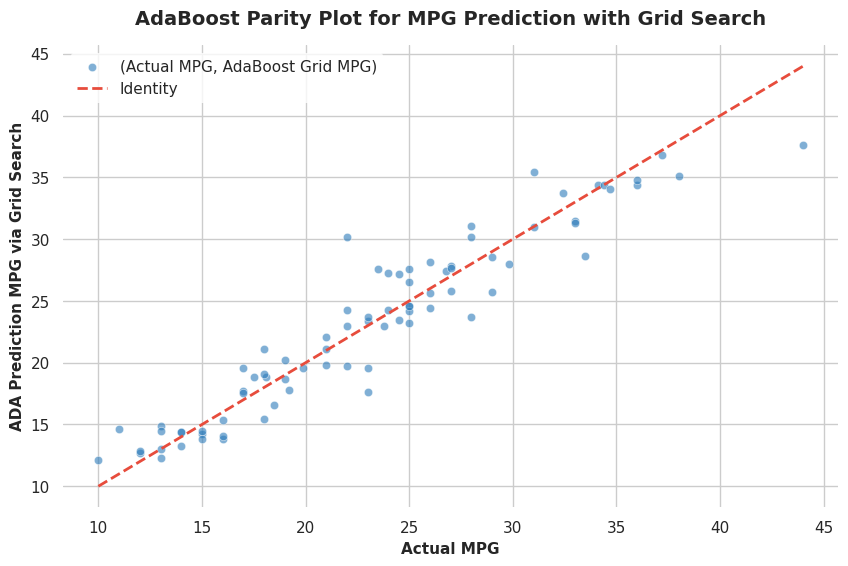

In [29]:
sns.set_theme(style='whitegrid', context="notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            pred_ADA_grid,
            color='#2b7bba',
            alpha=0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(Actual MPG, AdaBoost Grid MPG)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='Identity'
)
plt.title('AdaBoost Parity Plot for MPG Prediction with Grid Search', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('Actual MPG', fontsize=11, fontweight='semibold')
plt.ylabel('ADA Prediction MPG via Grid Search', fontsize=11, fontweight='semibold')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.show()

# **4.- XGBoost**

## **4.1 .- Baseline model**

We define the baseline model with hyperparameters



In [30]:
XGB = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,

    min_child_weight = 5,
    gamma = 0.1,

    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,

    reg_alpha = 0.1,
    reg_lambda = 1.0,

    random_state = 42
                    )

Training model

In [31]:
XGB.fit(X_train, Y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

We make log-transformed predictions

In [32]:
Y_pred_xgb_log = XGB.predict(X_test)
#print(Y_pred_xgb)

#we using exponential function
Y_pred_xgb = np.expm1(Y_pred_xgb_log)

We evaluate model using **RMSE**, **RMSE**, **MAE**

In [33]:
mse_xgb = mean_squared_error(
    y_test,
    Y_pred_xgb
)

rmse_xgb = np.sqrt(mse_xgb)

mae_xgb = mean_absolute_error(
    y_test, Y_pred_xgb
)

r2_xgb = r2_score(y_test, Y_pred_xgb)

print(f'MSE:{mse_xgb}')
print(f'RMSE: {rmse_xgb}')
print(f'MAE: {mae_xgb}')
print(f'R^2: {r2_xgb}')

MSE:5.085667548651984
RMSE: 2.255142467484479
MAE: 1.7273524761199952
R^2: 0.9054118666970236


Visualitation

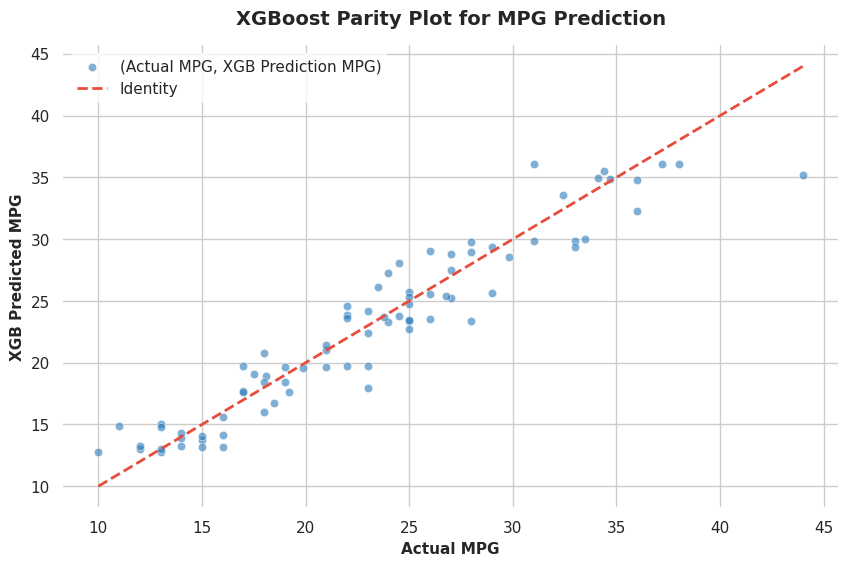

In [34]:
sns.set_theme(style ='whitegrid', context = "notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            Y_pred_xgb,
            color = '#2b7bba',
            alpha = 0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(Actual MPG, XGB Prediction MPG)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = '#e74c3c',
    linestyle = '--',
    linewidth = 2,
    label = 'Identity'
)
plt.title('XGBoost Parity Plot for MPG Prediction', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('Actual MPG', fontsize = 11, fontweight='semibold')
plt.ylabel('XGB Predicted MPG', fontsize =11, fontweight='semibold')
plt.legend(frameon = True, facecolor='white', edgecolor='none')
sns.despine(left = True, bottom = True)
plt.show()

## **4.2 .- GridSearchCV for XGBoost**



In [37]:
#  GridSearchCV — XGBoost
# Hyperparameter search with cross-validation.
# Total combinations: 64 (previously ~729). Equivalent result.
params_XGB = {
    'max_depth' : [3,4,5],
    'learning_rate' : [0.01, 0.05, 0.07],
    'n_estimators' :[200,300,400],
    'reg_alpha' : [0.01, 0.03, 0.04],
    'reg_lambda' : [1.0, 3.0, 4.0],
    'gamma' : [0.1, 0.2,0.3],
    #'min_child_weight' : [3, 5, 6]
}

# we create the model

model_XGB = XGBRegressor(
    subsample =0.8,
    colsample_bytree = 0.8,
    random_state=42
)

# we execute the model

grid_XGB = GridSearchCV(
    estimator = model_XGB,
    param_grid = params_XGB,
    cv = 5,
    scoring='r2',
    n_jobs = -1
)


grid_XGB.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    l...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0.1, 0.2, 0.3],
                         'learning_rate': [0.01, 0.05, 0.07],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [200, 300, 400],
                         'reg_alpha': [0.01, 0.03, 0.04],
                         'reg_lambda': [1.0, 3.0, 4.0]},
             scoring='r2')

We seen the best parameters

In [38]:
print(grid_XGB.best_params_)

{'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.04, 'reg_lambda': 3.0}


We training the best model

In [39]:
best_xgb_grid = grid_XGB.best_estimator_

We generate predictions and evaluate the model's performance

In [40]:
y_pred_XGB_grid = best_xgb_grid.predict(X_test)

mse_grid = mean_squared_error(y_test, y_pred_XGB_grid)
rmse_grid = mse_grid**0.5
mae_grid = mean_absolute_error(y_test, y_pred_XGB_grid)
r2_grid = r2_score(y_test, y_pred_XGB_grid)

print(f'RMSE: {rmse_grid}')
#print(f'MSE: {mse_grid}')
print(f'MAE: {mae_grid}')
print(f'R^2: {r2_grid}')

RMSE: 2.337542834998528
MAE: 1.7543692421913146
R^2: 0.8983732952311365


We generate a visualization XGB using GridSearchCV

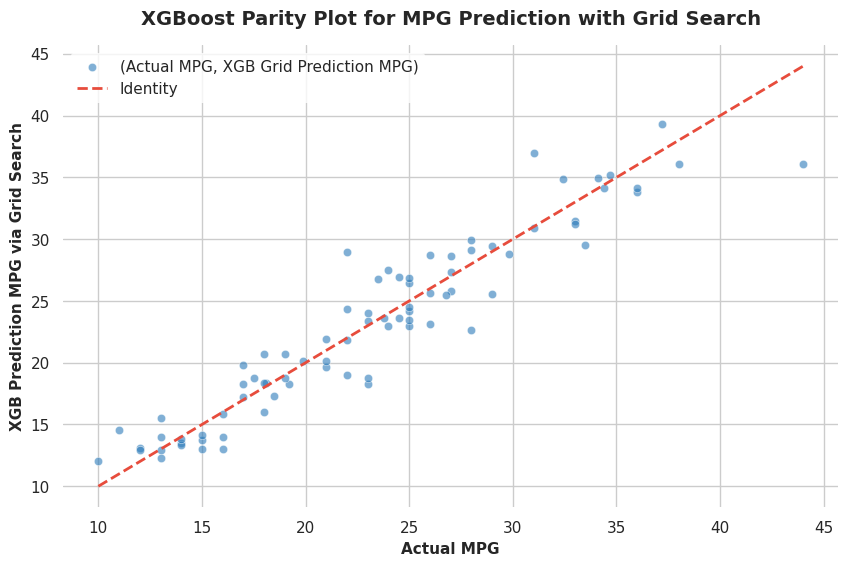

In [41]:
sns.set_theme(style='whitegrid', context="notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            y_pred_XGB_grid,
            color='#2b7bba',
            alpha=0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(Actual MPG, XGB Grid Prediction MPG)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='Identity'
)
plt.title('XGBoost Parity Plot for MPG Prediction with Grid Search', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('Actual MPG', fontsize =11, fontweight='semibold')
plt.ylabel('XGB Prediction MPG via Grid Search', fontsize =11, fontweight='semibold')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.show()

# **5.- Features Importance according to the models.**

In [43]:
# we create a DF with AdaBoost feature importances

dfAda_features_imp = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : best_ADA_grid.feature_importances_
}).sort_values(by = 'importance', ascending = False)

# we create a df with XGBoost feature importances

dfXGB_features_imp = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : best_xgb_grid.feature_importances_
}).sort_values(by = 'importance', ascending = False)

Importance Features Plot

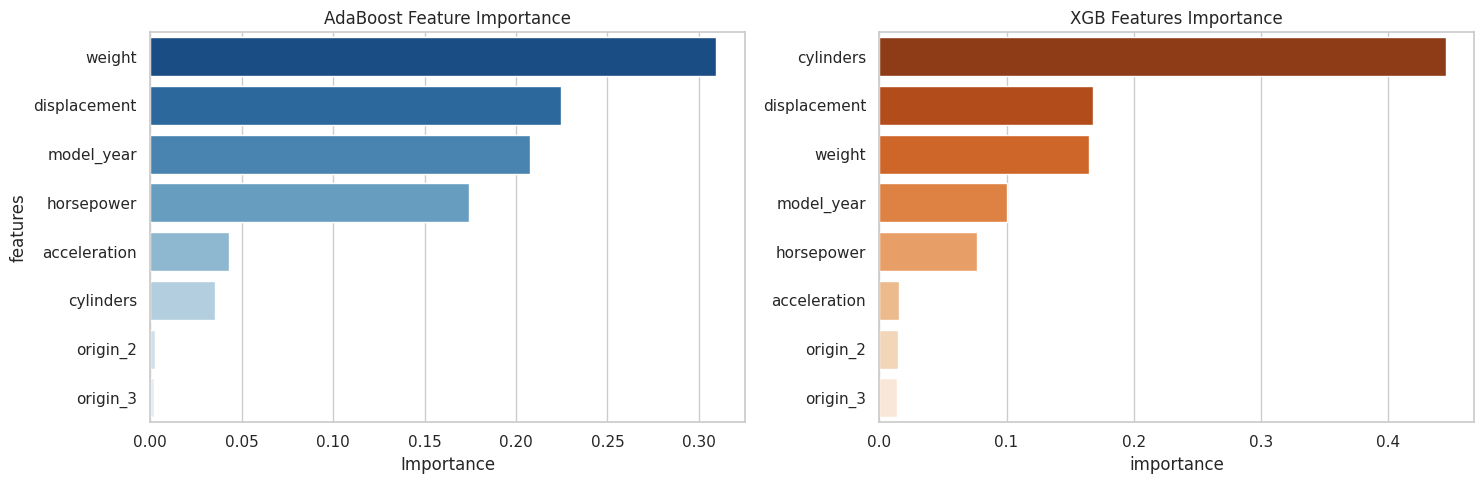

In [44]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

#graf for Ada
sns.barplot(x = 'importance', y = 'feature', hue = 'feature', data = dfAda_features_imp, ax = axes[0], palette='Blues_r')
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('features')

#graf for XGB
sns.barplot(x = 'importance', y = 'feature', hue= 'feature', data = dfXGB_features_imp, ax=axes[1], palette = 'Oranges_r')
axes[1].set_title('XGB Features Importance')
axes[1].set_xlabel('importance')
axes[1].set_ylabel('')

#graf for ada using cross validation
sns.barplot(x = 'importance', y = 'feature', hue = 'feature', data = dfAda_features_imp, ax = axes[0], palette='Blues_r')
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('features')


#plot
plt.tight_layout()
plt.show()

The feature importance evaluations for AdaBoost and XGBoost are diferent. However, the variables with higher importance aling logically with the domain problem, since higher weight vehicle requires more fuel consumption. Similarly, a higher number a cylinders also leads to higher fuel consumption.

Finally, we compared the performance of the models

In [45]:
evaluacion = pd.DataFrame({
    "modelo" : ["AdaBoost", "XGBoost", "AdaBoost GS", "XGB GS"],
    "MSE" : [mse_ADA, mse_xgb, mse_grid_ada, mse_grid],
    "RMSE" : [rmse_ADA, rmse_xgb, rmse_grid_ada, rmse_grid],
    "MAE" : [mae_ADA, mae_xgb, mae_grid_ada, mae_grid],
    "R^2" : [r2_ADA, r2_xgb, r2_grid_ada, r2_grid]
})
print(evaluacion)

        modelo       MSE      RMSE       MAE       R^2
0     AdaBoost  5.916653  2.432417  1.740009  0.889956
1      XGBoost  5.085668  2.255142  1.727352  0.905412
2  AdaBoost GS  5.047474  2.246658  1.668132  0.906122
3       XGB GS  5.464107  2.337543  1.754369  0.898373


By implementing tuned hyperparameters according to the specific problem, we observed an improvement in XGB compared to ADA. The key parameters driving this improvement were `reg_alpha=0.1`, `reg_lambda=1.0`, `gamma=1.0`, and `min_child_weight=5`. Upon incorporating these hyperparameters into XGB, the evaluation metrics improved, reaching levels similar to those obtained with ADA."

In [47]:
evaluacion.to_csv(os.path.join(DATA, 'metricas_boosting.csv'), index=False)

# the verification were saved
import os
print("Files in data/:")
for a in sorted(os.listdir(DATA)):
    if not a.startswith('.'):
        print(f"  - {a}")

Files in data/:
  - metricas_boosting.csv
  - processed


# **6.- Error distribution plot**

## **6.1 .- Error distribution plot of AdaBoost**

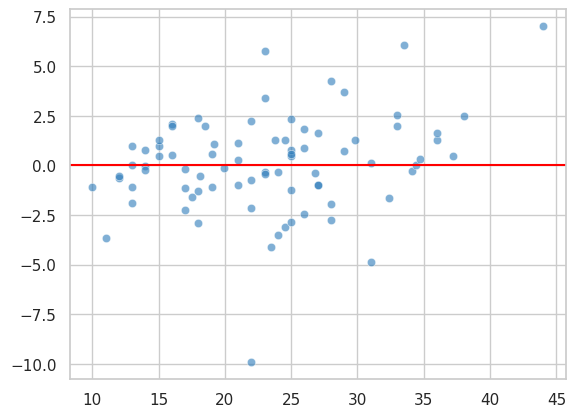

In [48]:
errors_ada = y_test - y_pred_ada
plt.scatter(y_test, errors_ada, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

## **6.2 .- Error distribution plot of AdaBoost using GridSearchCV**

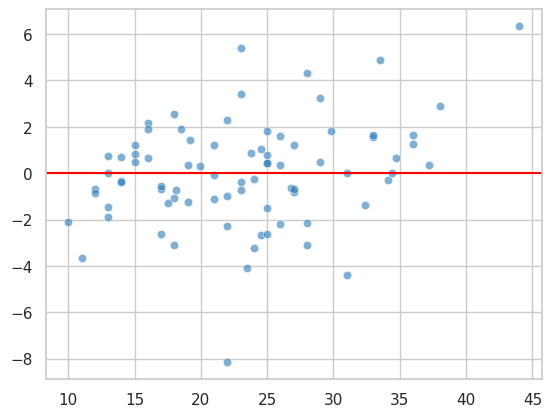

In [49]:
errors_ada_grid = y_test - pred_ADA_grid
plt.scatter(y_test, errors_ada_grid, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

## **6.3 .- Error distribution plot of XGBoost**

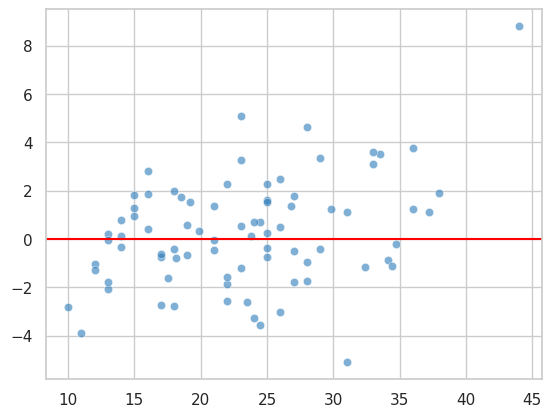

In [50]:
errors_xgb = y_test - Y_pred_xgb
plt.scatter(y_test, errors_xgb, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

## **6.4 .- Error distribution plot of XGBoost using GridSearchCV**

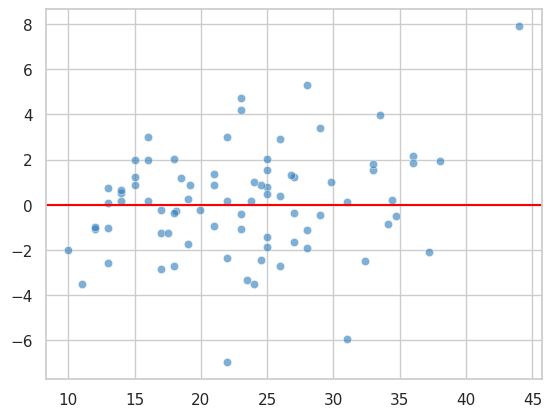

In [51]:
errors_xgb_grid = y_test - y_pred_XGB_grid
plt.scatter(y_test, errors_xgb_grid, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')